# Bank Marketing — Term Deposit Subscription Classifier

**BITS Pilani WILP · M.Tech (AIML) · Machine Learning Assignment 2**

Six classification models on the UCI Bank Marketing dataset, evaluated on
Accuracy, AUC, Precision, Recall, F1 and MCC.

Executed on **BITS Virtual Lab**.

---
### Contents
1. Environment
2. Load the dataset
3. Exploratory checks — and the `pdays` sentinel trap
4. Preprocessing pipeline
5. Train all six models
6. Comparison table
7. Threshold sensitivity — why 0.50 is arbitrary
8. Target leakage in `duration`
9. Persist the fitted models

## 1. Environment

Versions are printed so the notebook output is self-documenting.

In [1]:
import sys, os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Works whether the notebook is launched from the repo root or from model/.
NOTEBOOK_DIR = Path.cwd()
MODEL_DIR = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "model" else NOTEBOOK_DIR / "model"
REPO_ROOT = MODEL_DIR.parent
sys.path.insert(0, str(MODEL_DIR))

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("repo root   ", REPO_ROOT)

python       3.11.9
numpy        2.3.3
pandas       2.3.2
scikit-learn 1.7.2
repo root    /Users/rgarg5/bits-ml-assignment-2


## 2. Load the dataset

`bank-full.csv` is **semicolon-delimited** — reading it with the default comma
separator yields a single-column frame, which is the first thing to get wrong.
The cell downloads the archive if it is not already present.

In [2]:
DATA_DIR = REPO_ROOT / ".data"
DATA_PATH = DATA_DIR / "bank-full.csv"

if not DATA_PATH.exists():
    import urllib.request, zipfile, io
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    print(f"downloading {URL} ...")
    with urllib.request.urlopen(URL) as response:
        outer = zipfile.ZipFile(io.BytesIO(response.read()))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        inner.extractall(DATA_DIR)
    print("done")

bank_df = pd.read_csv(DATA_PATH, sep=";")
print(f"shape: {bank_df.shape[0]:,} rows x {bank_df.shape[1]} columns "
      f"({bank_df.shape[1] - 1} features + target)")
bank_df.head()

shape: 45,211 rows x 17 columns (16 features + target)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Exploratory checks

Three things decide how the rest of the notebook is built: the class balance, the
absence of true nulls, and the `pdays` sentinel.

In [3]:
print("--- assignment requirements ---")
print(f"instances : {bank_df.shape[0]:,}   (need >= 500)   -> {'PASS' if bank_df.shape[0] >= 500 else 'FAIL'}")
print(f"features  : {bank_df.shape[1] - 1}       (need >= 12)    -> {'PASS' if bank_df.shape[1] - 1 >= 12 else 'FAIL'}")

print("\n--- class balance ---")
balance = bank_df["y"].value_counts()
print(balance.to_string())
positive_rate = (bank_df["y"] == "yes").mean()
print(f"\npositive rate            : {positive_rate:.4f}  ({positive_rate:.1%})")
print(f"majority-class baseline  : {1 - positive_rate:.4f}")
print("\n>> Predicting 'no' for every client already scores "
      f"{1 - positive_rate:.1%} accuracy.")
print(">> Accuracy is therefore near-useless here; MCC and AUC carry the signal.")

print("\n--- missing values ---")
print(f"true nulls across all columns: {bank_df.isna().sum().sum()}")
print("('unknown' is used as an explicit category instead of NaN)")

--- assignment requirements ---
instances : 45,211   (need >= 500)   -> PASS
features  : 16       (need >= 12)    -> PASS

--- class balance ---
y
no     39922
yes     5289

positive rate            : 0.1170  (11.7%)
majority-class baseline  : 0.8830

>> Predicting 'no' for every client already scores 88.3% accuracy.
>> Accuracy is therefore near-useless here; MCC and AUC carry the signal.

--- missing values ---
true nulls across all columns: 0
('unknown' is used as an explicit category instead of NaN)


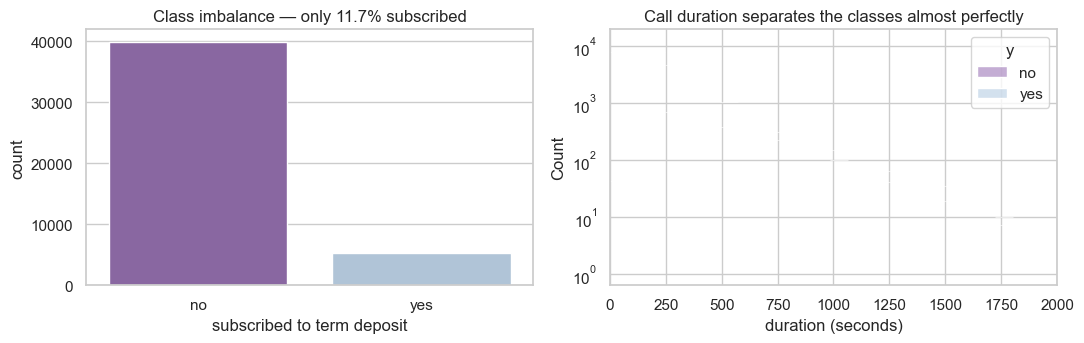

The right-hand plot is the leakage warning: 'duration' is only known AFTER
the call ends, so it cannot inform the decision of whom to call.
Quantified in section 8.


In [4]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))

sns.countplot(data=bank_df, x="y", ax=axes[0], hue="y", palette="BuPu_r", legend=False)
axes[0].set_title(f"Class imbalance — only {positive_rate:.1%} subscribed")
axes[0].set_xlabel("subscribed to term deposit")

sns.histplot(data=bank_df, x="duration", hue="y", bins=60, ax=axes[1],
             palette="BuPu_r", log_scale=(False, True))
axes[1].set_xlim(0, 2000)
axes[1].set_title("Call duration separates the classes almost perfectly")
axes[1].set_xlabel("duration (seconds)")

plt.tight_layout()
plt.show()

print("The right-hand plot is the leakage warning: 'duration' is only known AFTER")
print("the call ends, so it cannot inform the decision of whom to call.")
print("Quantified in section 8.")

### The `pdays` sentinel trap

`pdays` = days since the client was last contacted, **but `-1` means "never
contacted before"**. That is a categorical flag hiding inside a numeric column.
Feeding it to `StandardScaler` untouched corrupts the feature's distribution.

In [5]:
never_contacted = (bank_df["pdays"] == -1)
print(f"rows with pdays == -1 : {never_contacted.sum():,} ({never_contacted.mean():.1%})")
print("\nraw pdays describe() — note how -1 drags the distribution:")
print(bank_df["pdays"].describe().round(2).to_string())
print("\nafter excluding the sentinel, the genuine values are:")
print(bank_df.loc[~never_contacted, "pdays"].describe().round(2).to_string())
print("\n>> Fix: split into a yes/no flag + a numeric column that is 0 when never")
print(">> contacted. This is what preprocessing.engineer_features() does,")
print(">> taking the feature count from 16 to 17.")

rows with pdays == -1 : 36,954 (81.7%)

raw pdays describe() — note how -1 drags the distribution:
count    45211.00
mean        40.20
std        100.13
min         -1.00
25%         -1.00
50%         -1.00
75%         -1.00
max        871.00

after excluding the sentinel, the genuine values are:
count    8257.00
mean      224.58
std       115.34
min         1.00
25%       133.00
50%       194.00
75%       327.00
max       871.00

>> Fix: split into a yes/no flag + a numeric column that is 0 when never
>> contacted. This is what preprocessing.engineer_features() does,
>> taking the feature count from 16 to 17.


## 4. Preprocessing pipeline

`preprocessing.py` and `evaluation.py` are shared with `app.py`, so the numbers
produced here are the same ones the deployed dashboard displays.

In [6]:
from preprocessing import (
    build_column_transformer,
    split_features_and_target,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
)
from evaluation import METRIC_ORDER, score_classifier, score_at_threshold, confusion_frame

features, target = split_features_and_target(bank_df)

print(f"numeric features     ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nfeature matrix: {features.shape}")

encoded_width = build_column_transformer().fit_transform(features).shape[1]
print(f"after one-hot encoding: {features.shape[0]:,} x {encoded_width} columns")
features.head()

numeric features     (7): ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'days_since_last_contact']
categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'contacted_in_past_campaign']

feature matrix: (45211, 17)


after one-hot encoding: 45,211 x 43 columns


,age,balance,day,duration,campaign,previous,days_since_last_contact,job,marital,education,default,housing,loan,contact,month,poutcome,contacted_in_past_campaign
0,58,2143,5,261,1,0,0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,44,29,5,151,1,0,0,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,33,2,5,76,1,0,0,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,47,1506,5,92,1,0,0,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,33,1,5,198,1,0,0,unknown,single,unknown,no,no,no,unknown,may,unknown,no


In [7]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Stratified so both halves keep the 11.7% positive rate — otherwise the held-out
# AUC and MCC are not comparable across runs.
feat_train, feat_test, target_train, target_test = train_test_split(
    features, target, test_size=0.25, stratify=target, random_state=RANDOM_SEED
)

print(f"train: {len(feat_train):,} rows  ({target_train.mean():.2%} positive)")
print(f"test : {len(feat_test):,} rows  ({target_test.mean():.2%} positive)")

train: 33,908 rows  (11.70% positive)
test : 11,303 rows  (11.70% positive)


## 5. Train all six models

Every model is wrapped in a `Pipeline` with the *same* `ColumnTransformer`, so the
table compares algorithms rather than preprocessing choices.

Note which estimators accept `class_weight` — Logistic Regression, Decision Tree
and Random Forest do; **kNN and Gaussian Naive Bayes do not**. That asymmetry
explains most of the results.

In [8]:
from train_models import build_model_zoo, slugify
from sklearn.pipeline import Pipeline
import time

model_zoo = build_model_zoo()
fitted_models, results = {}, []

for display_name, estimator in model_zoo.items():
    pipeline = Pipeline([
        ("encode", build_column_transformer()),
        ("classify", estimator),
    ])
    started = time.perf_counter()
    pipeline.fit(feat_train, target_train)
    elapsed = time.perf_counter() - started

    scores = score_classifier(pipeline, feat_test, target_test)
    fitted_models[display_name] = pipeline
    results.append({"ML Model Name": display_name, **scores})

    print(f"{display_name:<32} acc={scores['Accuracy']:.4f}  auc={scores['AUC']:.4f}  "
          f"f1={scores['F1']:.4f}  mcc={scores['MCC']:.4f}   ({elapsed:.2f}s)")

Logistic Regression              acc=0.8477  auc=0.9085  f1=0.5562  mcc=0.5130   (0.07s)
Decision Tree                    acc=0.7963  auc=0.8965  f1=0.5035  mcc=0.4713   (0.12s)


kNN                              acc=0.8963  auc=0.8942  f1=0.3603  mcc=0.3586   (0.04s)
Naive Bayes                      acc=0.8556  auc=0.8052  f1=0.4445  mcc=0.3649   (0.05s)


Random Forest (Ensemble)         acc=0.8489  auc=0.9239  f1=0.5685  mcc=0.5317   (0.61s)


Gradient Boosting (Ensemble)     acc=0.9078  auc=0.9327  f1=0.5393  mcc=0.4985   (2.36s)


## 6. Comparison table

In [9]:
comparison = pd.DataFrame(results).set_index("ML Model Name")[METRIC_ORDER]
baseline_accuracy = 1 - target_test.mean()

print(f"Held-out test set: {len(feat_test):,} rows | threshold 0.50 | "
      f"majority-class baseline accuracy = {baseline_accuracy:.4f}\n")
print(comparison.round(4).to_string())

print("\nbest model per metric:")
for metric in METRIC_ORDER:
    winner = comparison[metric].idxmax()
    print(f"  {metric:<10} {winner:<32} {comparison.loc[winner, metric]:.4f}")

below = comparison.index[comparison["Accuracy"] < baseline_accuracy].tolist()
print(f"\n>> {len(below)} models score BELOW the do-nothing baseline on accuracy:")
for name in below:
    print(f"     {name:<32} acc={comparison.loc[name, 'Accuracy']:.4f}  mcc={comparison.loc[name, 'MCC']:.4f}")
knn_mcc = comparison.loc["kNN", "MCC"]
print(f">> Yet all {len(below)} beat kNN (mcc={knn_mcc:.4f}), which BEATS the baseline on")
print(">> accuracy. Reading the accuracy column alone ranks these models backwards.")

Held-out test set: 11,303 rows | threshold 0.50 | majority-class baseline accuracy = 0.8830

                              Accuracy     AUC  Precision  Recall      F1     MCC
ML Model Name                                                                    
Logistic Regression             0.8477  0.9085     0.4218  0.8162  0.5562  0.5130
Decision Tree                   0.7963  0.8965     0.3521  0.8828  0.5035  0.4713
kNN                             0.8963  0.8942     0.6471  0.2496  0.3603  0.3586
Naive Bayes                     0.8556  0.8052     0.4041  0.4939  0.4445  0.3649
Random Forest (Ensemble)        0.8489  0.9239     0.4268  0.8510  0.5685  0.5317
Gradient Boosting (Ensemble)    0.9078  0.9327     0.6489  0.4614  0.5393  0.4985

best model per metric:
  Accuracy   Gradient Boosting (Ensemble)     0.9078
  AUC        Gradient Boosting (Ensemble)     0.9327
  Precision  Gradient Boosting (Ensemble)     0.6489
  Recall     Decision Tree                    0.8828
  F1         Ra

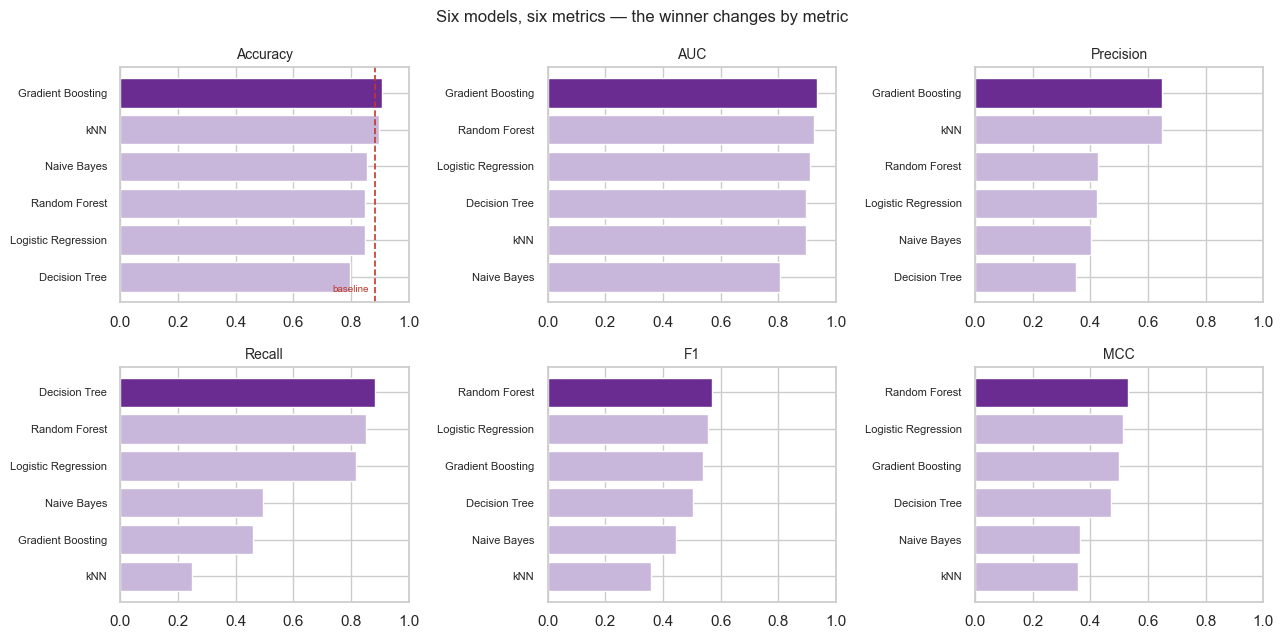

In [10]:
figure, axes = plt.subplots(2, 3, figsize=(13, 6.5))

for axis, metric in zip(axes.ravel(), METRIC_ORDER):
    ordered = comparison[metric].sort_values()
    colours = ["#6A2C91" if v == ordered.max() else "#C9B6DB" for v in ordered]
    axis.barh(range(len(ordered)), ordered.values, color=colours)
    axis.set_yticks(range(len(ordered)))
    axis.set_yticklabels([n.replace(" (Ensemble)", "") for n in ordered.index], fontsize=8)
    axis.set_title(metric, fontsize=10)
    axis.set_xlim(0, 1)
    if metric == "Accuracy":
        axis.axvline(baseline_accuracy, color="#C0392B", linestyle="--", linewidth=1.2)
        axis.text(baseline_accuracy - 0.02, -0.4, "baseline", color="#C0392B",
                  fontsize=7, ha="right")

plt.suptitle("Six models, six metrics — the winner changes by metric", fontsize=12)
plt.tight_layout()
plt.show()

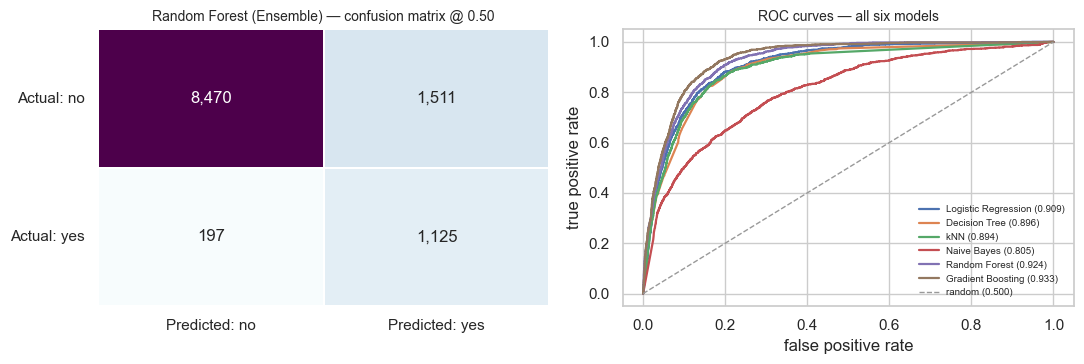

Classification report — Random Forest (Ensemble)

                        precision    recall  f1-score   support

no (did not subscribe)       0.98      0.85      0.91      9981
      yes (subscribed)       0.43      0.85      0.57      1322

              accuracy                           0.85     11303
             macro avg       0.70      0.85      0.74     11303
          weighted avg       0.91      0.85      0.87     11303



In [11]:
best_by_mcc = comparison["MCC"].idxmax()
best_pipeline = fitted_models[best_by_mcc]
_, best_predictions = score_at_threshold(best_pipeline, feat_test, target_test, 0.50)

figure, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sns.heatmap(confusion_frame(target_test, best_predictions), annot=True, fmt=",d",
            cmap="BuPu", cbar=False, linewidths=1.2, linecolor="white", ax=axes[0])
axes[0].set_title(f"{best_by_mcc} — confusion matrix @ 0.50", fontsize=10)
plt.setp(axes[0].get_yticklabels(), rotation=0)

from sklearn.metrics import roc_curve
from evaluation import positive_class_scores
for display_name, pipeline in fitted_models.items():
    fpr, tpr, _ = roc_curve(target_test, positive_class_scores(pipeline, feat_test))
    axes[1].plot(fpr, tpr, linewidth=1.6,
                 label=f"{display_name.replace(' (Ensemble)', '')} ({comparison.loc[display_name, 'AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="#999999", linewidth=1, label="random (0.500)")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curves — all six models", fontsize=10)
axes[1].legend(fontsize=7, loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
print(f"Classification report — {best_by_mcc}\n")
print(classification_report(target_test, best_predictions,
                            target_names=["no (did not subscribe)", "yes (subscribed)"],
                            zero_division=0))

## 7. Threshold sensitivity

0.50 is a **convention**, not a property of the data. Because kNN and Naive Bayes
cannot be class-weighted, a 0.50 cut-off on an 11.7%-positive problem penalises
them structurally. Sweeping the threshold separates *ranking ability* from
*calibration*.

In [12]:
sweep_rows = []
for display_name, pipeline in fitted_models.items():
    for threshold in np.arange(0.05, 1.0, 0.05):
        metrics, _ = score_at_threshold(pipeline, feat_test, target_test, threshold)
        sweep_rows.append({"model": display_name, "threshold": round(threshold, 2), **metrics})

sweep = pd.DataFrame(sweep_rows)
best_tuned = (sweep.loc[sweep.groupby("model")["MCC"].idxmax()]
                   .set_index("model")[["threshold", "MCC", "F1", "Precision", "Recall"]])
best_tuned["MCC @ 0.50"] = comparison["MCC"]
best_tuned["gain"] = best_tuned["MCC"] - best_tuned["MCC @ 0.50"]

print("Best achievable MCC per model, and the threshold that achieves it:\n")
print(best_tuned[["MCC @ 0.50", "MCC", "threshold", "gain"]]
      .sort_values("MCC", ascending=False).round(4).to_string())

champion = best_tuned["MCC"].idxmax()
print(f"\n>> Threshold-tuned winner: {champion} "
      f"(MCC {best_tuned.loc[champion, 'MCC']:.4f} @ {best_tuned.loc[champion, 'threshold']:.2f})")
print(f">> Largest gain from tuning alone: {best_tuned['gain'].idxmax()} "
      f"(+{best_tuned['gain'].max():.4f} MCC)")
auc_spread = comparison["AUC"].max() - comparison["AUC"].min()
print(f">> For comparison, the best-to-worst AUC spread across all six models is only "
      f"{auc_spread:.4f}.")
print(">> Tuning one model's threshold moved MCC further than the entire algorithmic")
print(">> spread: choosing the right THRESHOLD matters more than the right ALGORITHM.")

Best achievable MCC per model, and the threshold that achieves it:

                              MCC @ 0.50     MCC  threshold    gain
model                                                              
Gradient Boosting (Ensemble)      0.4985  0.5838       0.25  0.0853
Random Forest (Ensemble)          0.5317  0.5463       0.65  0.0147
Logistic Regression               0.5130  0.5288       0.65  0.0157
kNN                               0.3586  0.5148       0.20  0.1563
Decision Tree                     0.4713  0.5036       0.65  0.0323
Naive Bayes                       0.3649  0.3688       0.70  0.0039

>> Threshold-tuned winner: Gradient Boosting (Ensemble) (MCC 0.5838 @ 0.25)
>> Largest gain from tuning alone: kNN (+0.1563 MCC)
>> For comparison, the best-to-worst AUC spread across all six models is only 0.1275.
>> Tuning one model's threshold moved MCC further than the entire algorithmic
>> spread: choosing the right THRESHOLD matters more than the right ALGORITHM.


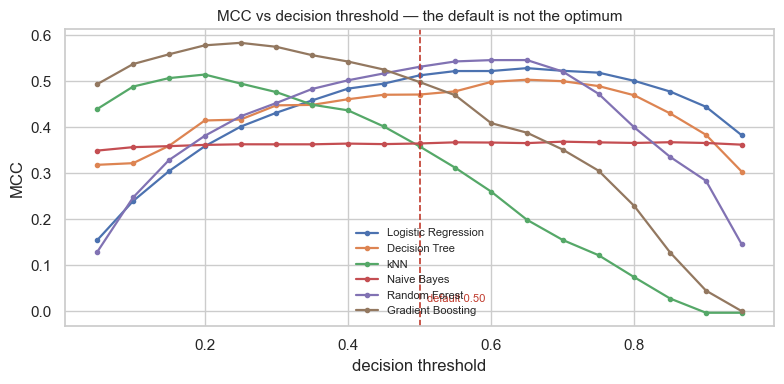

In [13]:
figure, axis = plt.subplots(figsize=(8, 4))
for display_name in fitted_models:
    subset = sweep[sweep["model"] == display_name]
    axis.plot(subset["threshold"], subset["MCC"], marker="o", markersize=3,
              linewidth=1.6, label=display_name.replace(" (Ensemble)", ""))
axis.axvline(0.50, color="#C0392B", linestyle="--", linewidth=1.2)
axis.text(0.51, 0.02, "default 0.50", color="#C0392B", fontsize=8)
axis.set_xlabel("decision threshold"); axis.set_ylabel("MCC")
axis.set_title("MCC vs decision threshold — the default is not the optimum", fontsize=11)
axis.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 8. Target leakage in `duration`

`duration` is the call length in seconds — known **only after the call ends**. A
model using it cannot decide whom to call. Retrained without it, the honest
performance ceiling is much lower.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def transformer_without(dropped: list[str]) -> ColumnTransformer:
    return ColumnTransformer([
        ("numeric", StandardScaler(), [c for c in NUMERIC_FEATURES if c not in dropped]),
        ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL_FEATURES),
    ], sparse_threshold=0)

leakage_rows = []
for label, dropped in [("with duration", []), ("without duration", ["duration"])]:
    for name, estimator in [
        ("Logistic Regression", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
        ("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=10,
                                                 class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_SEED)),
    ]:
        pipeline = Pipeline([("encode", transformer_without(dropped)), ("classify", estimator)])
        pipeline.fit(feat_train, target_train)
        leakage_rows.append({"model": name, "variant": label,
                             **score_classifier(pipeline, feat_test, target_test)})

leakage = pd.DataFrame(leakage_rows).pivot(index="model", columns="variant")
for metric in ["AUC", "MCC"]:
    block = leakage[metric]
    block = block.assign(drop=block["with duration"] - block["without duration"])
    print(f"--- {metric} ---")
    print(block.round(4).to_string())
    print()

forest = fitted_models["Random Forest (Ensemble)"]
names = [n.split("__", 1)[-1] for n in forest.named_steps["encode"].get_feature_names_out()]
importance = pd.Series(forest.named_steps["classify"].feature_importances_,
                       index=names).sort_values(ascending=False)
print("Random Forest — top 8 feature importances:")
print(importance.head(8).round(4).to_string())
print(f"\n>> 'duration' alone accounts for {importance['duration']:.1%} of total importance,")
print(">> more than the other 42 encoded features combined.")
print(">> Every headline number above is optimistic for a real pre-call model.")

--- AUC ---
variant              with duration  without duration    drop
model                                                       
Logistic Regression         0.9085            0.7731  0.1354
Random Forest               0.9239            0.7979  0.1260

--- MCC ---
variant              with duration  without duration    drop
model                                                       
Logistic Regression         0.5130            0.2883  0.2248
Random Forest               0.5317            0.3782  0.1535

Random Forest — top 8 feature importances:
duration                   0.4688
poutcome_success           0.0623
contact_unknown            0.0559
age                        0.0469
housing_yes                0.0403
balance                    0.0399
days_since_last_contact    0.0336
day                        0.0336

>> 'duration' alone accounts for 46.9% of total importance,
>> more than the other 42 encoded features combined.
>> Every headline number above is optimistic for a real p

## 9. Persist the fitted models

Saves one `.joblib` per model for `app.py`, plus the held-out split in **raw**
form so the Streamlit upload path exercises the same feature-engineering code
used in training.

In [15]:
for display_name, pipeline in fitted_models.items():
    path = MODEL_DIR / f"{slugify(display_name)}.joblib"
    joblib.dump(pipeline, path, compress=3)
    print(f"{path.name:<38} {path.stat().st_size / 1024**2:6.2f} MB")

raw_test_split = bank_df.loc[feat_test.index]
test_csv = REPO_ROOT / "test_data.csv"
raw_test_split.to_csv(test_csv, index=False)
print(f"\n{test_csv.name:<38} {len(raw_test_split):,} rows (raw format, includes 'y')")

print("\nNext: streamlit run app.py")

logistic_regression.joblib               0.00 MB
decision_tree.joblib                     0.01 MB
knn.joblib                               1.26 MB
naive_bayes.joblib                       0.00 MB


random_forest_ensemble.joblib            5.91 MB
gradient_boosting_ensemble.joblib        0.15 MB



test_data.csv                          11,303 rows (raw format, includes 'y')

Next: streamlit run app.py


## Conclusion

| Finding | Evidence |
|---|---|
| Accuracy is misleading on this dataset | Majority-class baseline is 88.3%; Logistic Regression and Decision Tree score *below* it yet have much higher MCC than kNN, which beats it |
| Random Forest is the best default | Top F1 and MCC at threshold 0.50 |
| Gradient Boosting is the strongest learner | Best AUC (threshold-independent) and the best tuned MCC of any model |
| kNN's weakness was calibration, not ranking | No `class_weight` support ⇒ collapses at 0.50, but MCC recovers sharply at ~0.20 |
| Naive Bayes is genuinely weakest | Worst AUC by a wide margin; conditional-independence assumption structurally violated |
| Threshold choice > algorithm choice | Retuning the cut-off moved one model's MCC more than the entire best-to-worst AUC spread |
| All results lean on a leaky feature | `duration` is ~47% of Random Forest importance and is unavailable before a call |

Full write-up in `README.md`; interactive version in `app.py`.